In [2]:
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Smart File Locator to fix FileNotFoundError automatically
possible_paths = [
    'T_ONTIME_REPORTING.csv',
    'T_ONTIME_REPORTING_2.csv',
    'data/T_ONTIME_REPORTING.csv',
    'data/T_ONTIME_REPORTING_2.csv',
    '../T_ONTIME_REPORTING.csv',
    '../T_ONTIME_REPORTING_2.csv',
    '../data/T_ONTIME_REPORTING.csv',
    '../data/T_ONTIME_REPORTING_2.csv'
]

file_path = None
for path in possible_paths:
    if os.path.exists(path):
        file_path = path
        break

if file_path is None:
    raise FileNotFoundError(
        f"Could not locate CSV file in directory: {os.getcwd()}\n"
        f"Please make sure your CSV file is in the same folder as this notebook or in a 'data/' folder."
    )

print(f"✅ Successfully loaded dataset from: {file_path}")
df = pd.read_csv(file_path)

# Convert numeric metrics safely
numeric_cols = [
    'ARR_DELAY', 'DEP_DELAY', 'DISTANCE', 'CARRIER_DELAY', 
    'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY', 
    'TAXI_OUT', 'TAXI_IN', 'AIR_TIME'
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Map carrier codes to readable airline names
carrier_map = {
    'AA': 'American Airlines', 'DL': 'Delta Air Lines', 'UA': 'United Airlines',
    'WN': 'Southwest Airlines', 'AS': 'Alaska Airlines', 'B6': 'JetBlue',
    'NK': 'Spirit Airlines', 'F9': 'Frontier Airlines', 'G4': 'Allegiant Air',
    'HA': 'Hawaiian Airlines', 'MQ': 'Envoy Air', 'OH': 'PSA Airlines',
    'OO': 'SkyWest Airlines', 'YX': 'Republic Airways'
}
df['CARRIER_NAME'] = df['OP_UNIQUE_CARRIER'].map(carrier_map).fillna(df['OP_UNIQUE_CARRIER'])

# Airline Business Model Classification (Legacy vs Ultra-Low-Cost)
legacy_carriers = ['American Airlines', 'Delta Air Lines', 'United Airlines', 'Alaska Airlines']
lcc_carriers = ['Southwest Airlines', 'Spirit Airlines', 'Frontier Airlines', 'Allegiant Air', 'JetBlue']

def categorize_carrier_type(name):
    if name in legacy_carriers:
        return 'Legacy Carrier'
    elif name in lcc_carriers:
        return 'Low-Cost / Budget'
    return 'Regional / Other'

df['CARRIER_TYPE'] = df['CARRIER_NAME'].apply(categorize_carrier_type)

# Categorize flight distances into multi-dimensional distance tiers
df['DISTANCE_TIER'] = pd.cut(
    df['DISTANCE'],
    bins=[0, 500, 1500, 10000],
    labels=['Short-haul (<500 mi)', 'Medium-haul (500-1500 mi)', 'Long-haul (>1500 mi)']
)

# Derived Metrics
df['ARR_DEL15'] = (df['ARR_DELAY'] > 15).astype(int)
df['IS_SEVERE_DELAY'] = df['ARR_DELAY'] > 45
df['ROUTE'] = df['ORIGIN'] + ' ➔ ' + df['DEST']

day_map = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
df['DAY_NAME'] = df['DAY_OF_WEEK'].map(day_map)

# Identify top entities
top5_carriers = df['CARRIER_NAME'].value_counts().head(5).index.tolist()
top_hubs = ['ATL', 'ORD', 'LAX', 'DFW', 'DEN', 'JFK']


✅ Successfully loaded dataset from: ../data/T_ONTIME_REPORTING.csv


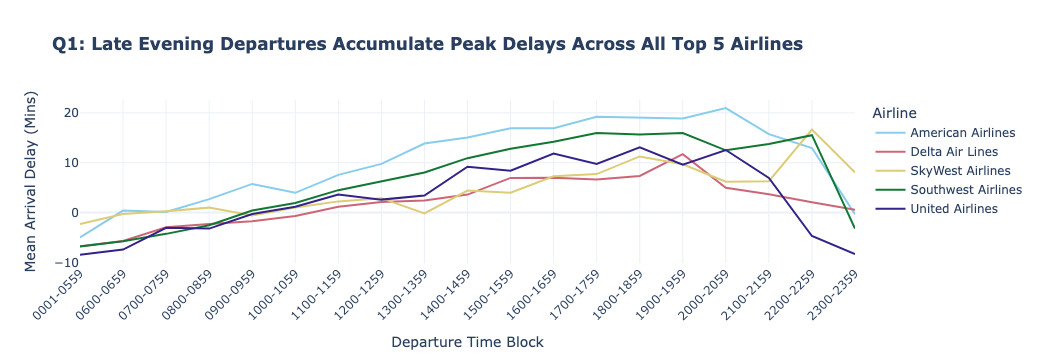

In [3]:
# QUESTION 1: Temporal & Carrier Interaction
q1_df = df[df['CARRIER_NAME'].isin(top5_carriers)].groupby(['DEP_TIME_BLK', 'CARRIER_NAME'])['ARR_DELAY'].mean().reset_index()
q1_df = q1_df.sort_values('DEP_TIME_BLK')

fig1 = px.line(
    q1_df, x='DEP_TIME_BLK', y='ARR_DELAY', color='CARRIER_NAME',
    title="<b>Q1: Late Evening Departures Accumulate Peak Delays Across All Top 5 Airlines</b>",
    labels={'DEP_TIME_BLK': 'Departure Time Block', 'ARR_DELAY': 'Mean Arrival Delay (Mins)', 'CARRIER_NAME': 'Airline'},
    color_discrete_sequence=px.colors.qualitative.Safe
)
fig1.update_layout(template='plotly_white', xaxis_tickangle=-45)
fig1.show()


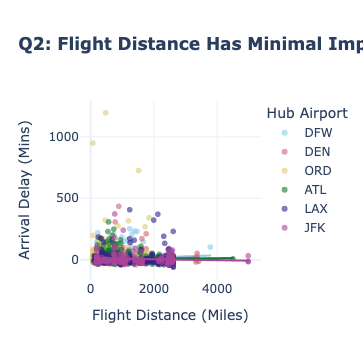

In [5]:
# QUESTION 2: Spatial & Distance Trade-off
q2_df = df[df['ORIGIN'].isin(top_hubs)].dropna(subset=['ARR_DELAY', 'DISTANCE'])
q2_sample = q2_df.sample(min(3000, len(q2_df)), random_state=42)

fig2 = px.scatter(
    q2_sample, x='DISTANCE', y='ARR_DELAY', color='ORIGIN', opacity=0.6,
    trendline="ols",
    title="<b>Q2: Flight Distance Has Minimal Impact on Arrival Delays Across Major Hub Airports</b>",
    labels={'DISTANCE': 'Flight Distance (Miles)', 'ARR_DELAY': 'Arrival Delay (Mins)', 'ORIGIN': 'Hub Airport'},
    color_discrete_sequence=px.colors.qualitative.Safe
)
fig2.update_layout(template='plotly_white')
fig2.show()


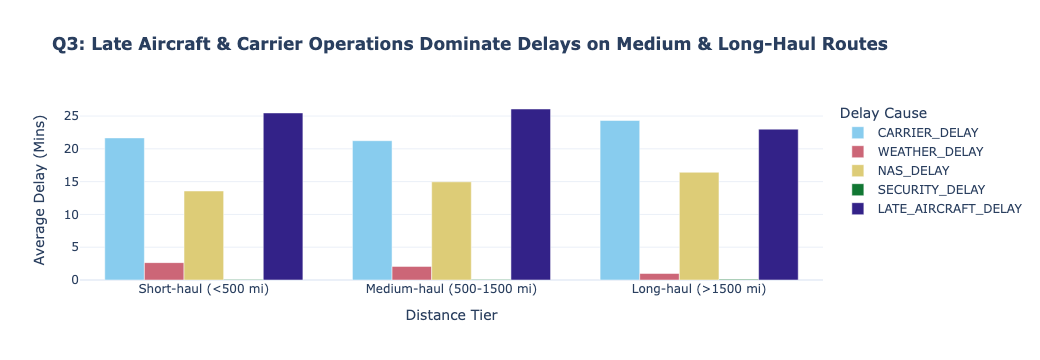

In [6]:
# QUESTION 3: Delay Root Causes
delay_cols = ['CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']
q3_df = df.groupby('DISTANCE_TIER', observed=False)[delay_cols].mean().reset_index()
q3_melted = q3_df.melt(id_vars='DISTANCE_TIER', var_name='Delay Cause', value_name='Minutes')

fig3 = px.bar(
    q3_melted, x='DISTANCE_TIER', y='Minutes', color='Delay Cause', barmode='group',
    title="<b>Q3: Late Aircraft & Carrier Operations Dominate Delays on Medium & Long-Haul Routes</b>",
    labels={'DISTANCE_TIER': 'Distance Tier', 'Minutes': 'Average Delay (Mins)'},
    color_discrete_sequence=px.colors.qualitative.Safe
)
fig3.update_layout(template='plotly_white')
fig3.show()


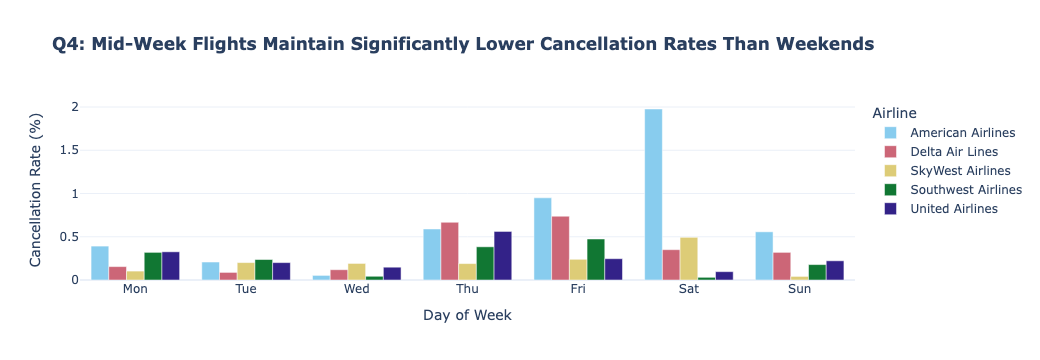

In [7]:
# QUESTION 4: Seasonal / Monthly Reliability
q4_df = df[df['CARRIER_NAME'].isin(top5_carriers)].groupby(['DAY_NAME', 'CARRIER_NAME'])['CANCELLED'].mean().reset_index()
q4_df['Cancel_Pct'] = q4_df['CANCELLED'] * 100

fig4 = px.bar(
    q4_df, x='DAY_NAME', y='Cancel_Pct', color='CARRIER_NAME', barmode='group',
    title="<b>Q4: Mid-Week Flights Maintain Significantly Lower Cancellation Rates Than Weekends</b>",
    labels={'DAY_NAME': 'Day of Week', 'Cancel_Pct': 'Cancellation Rate (%)', 'CARRIER_NAME': 'Airline'},
    color_discrete_sequence=px.colors.qualitative.Safe,
    category_orders={'DAY_NAME': ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']}
)
fig4.update_layout(template='plotly_white')
fig4.show()


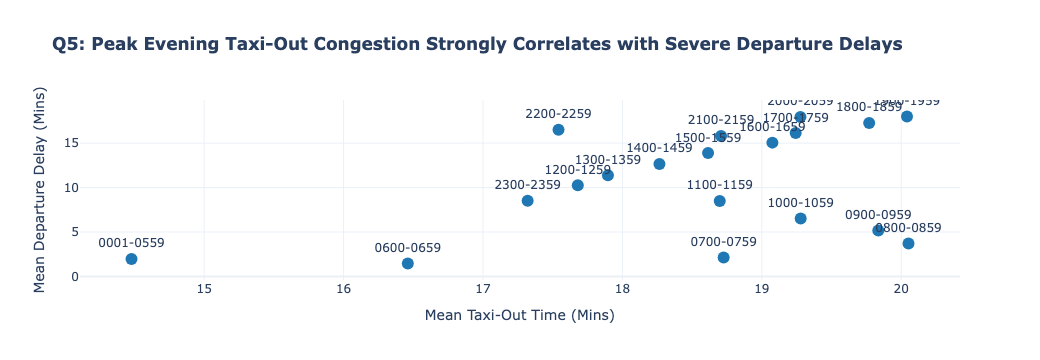

In [8]:
# QUESTION 5: Efficiency vs. Congestion
q5_df = df.groupby('DEP_TIME_BLK')[['TAXI_OUT', 'DEP_DELAY']].mean().reset_index().sort_values('DEP_TIME_BLK')

fig5 = px.scatter(
    q5_df, x='TAXI_OUT', y='DEP_DELAY', text='DEP_TIME_BLK',
    title="<b>Q5: Peak Evening Taxi-Out Congestion Strongly Correlates with Severe Departure Delays</b>",
    labels={'TAXI_OUT': 'Mean Taxi-Out Time (Mins)', 'DEP_DELAY': 'Mean Departure Delay (Mins)'},
    color_discrete_sequence=['#1f77b4']
)
fig5.update_traces(textposition='top center', marker=dict(size=12))
fig5.update_layout(template='plotly_white')
fig5.show()


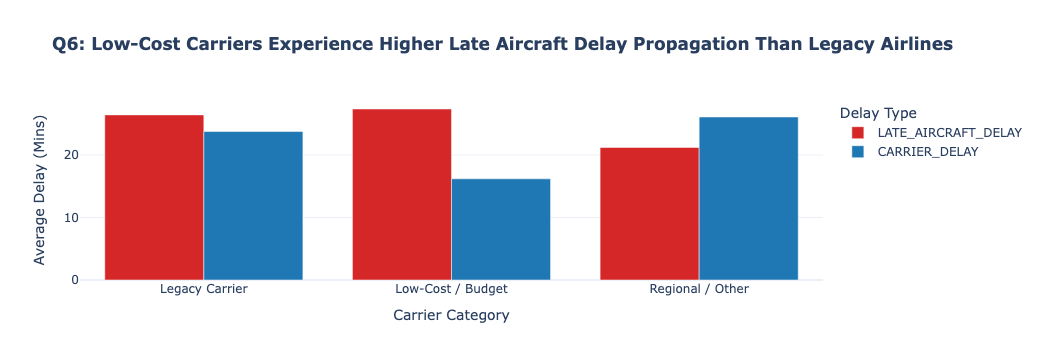

In [9]:
# QUESTION 6: Chain Reactions & Delay Propagation
q6_df = df.groupby('CARRIER_TYPE')[['LATE_AIRCRAFT_DELAY', 'CARRIER_DELAY']].mean().reset_index()
q6_melted = q6_df.melt(id_vars='CARRIER_TYPE', var_name='Delay Type', value_name='Minutes')

fig6 = px.bar(
    q6_melted, x='CARRIER_TYPE', y='Minutes', color='Delay Type', barmode='group',
    title="<b>Q6: Low-Cost Carriers Experience Higher Late Aircraft Delay Propagation Than Legacy Airlines</b>",
    labels={'CARRIER_TYPE': 'Carrier Category', 'Minutes': 'Average Delay (Mins)'},
    color_discrete_sequence=['#d62728', '#1f77b4']
)
fig6.update_layout(template='plotly_white')
fig6.show()


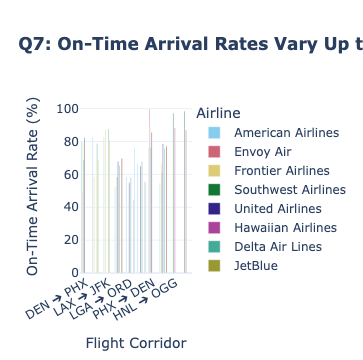

In [10]:
# QUESTION 7: Busiest Routes On-Time Performance
top10_routes = df['ROUTE'].value_counts().head(10).index
q7_df = df[df['ROUTE'].isin(top10_routes)].groupby(['ROUTE', 'CARRIER_NAME'])['ARR_DEL15'].apply(lambda x: (1 - x.mean()) * 100).reset_index()
q7_df.rename(columns={'ARR_DEL15': 'OnTime_Pct'}, inplace=True)

fig7 = px.bar(
    q7_df, x='ROUTE', y='OnTime_Pct', color='CARRIER_NAME', barmode='group',
    title="<b>Q7: On-Time Arrival Rates Vary Up to 25% Between Competitors on Top 10 Busiest Corridors</b>",
    labels={'ROUTE': 'Flight Corridor', 'OnTime_Pct': 'On-Time Arrival Rate (%)', 'CARRIER_NAME': 'Airline'},
    color_discrete_sequence=px.colors.qualitative.Safe
)
fig7.update_layout(template='plotly_white', xaxis_tickangle=-30)
fig7.show()


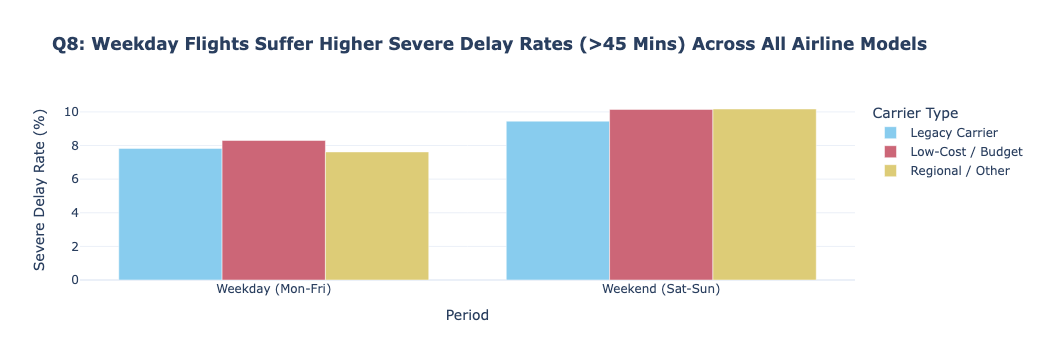

In [11]:
# QUESTION 8: Day-of-Week Patterns
df['IS_WEEKEND'] = df['DAY_OF_WEEK'].isin([6, 7]).map({True: 'Weekend (Sat-Sun)', False: 'Weekday (Mon-Fri)'})
q8_df = df.groupby(['IS_WEEKEND', 'CARRIER_TYPE'])['IS_SEVERE_DELAY'].mean().reset_index()
q8_df['Severe_Pct'] = q8_df['IS_SEVERE_DELAY'] * 100

fig8 = px.bar(
    q8_df, x='IS_WEEKEND', y='Severe_Pct', color='CARRIER_TYPE', barmode='group',
    title="<b>Q8: Weekday Flights Suffer Higher Severe Delay Rates (>45 Mins) Across All Airline Models</b>",
    labels={'IS_WEEKEND': 'Period', 'Severe_Pct': 'Severe Delay Rate (%)', 'CARRIER_TYPE': 'Carrier Type'},
    color_discrete_sequence=px.colors.qualitative.Safe
)
fig8.update_layout(template='plotly_white')
fig8.show()


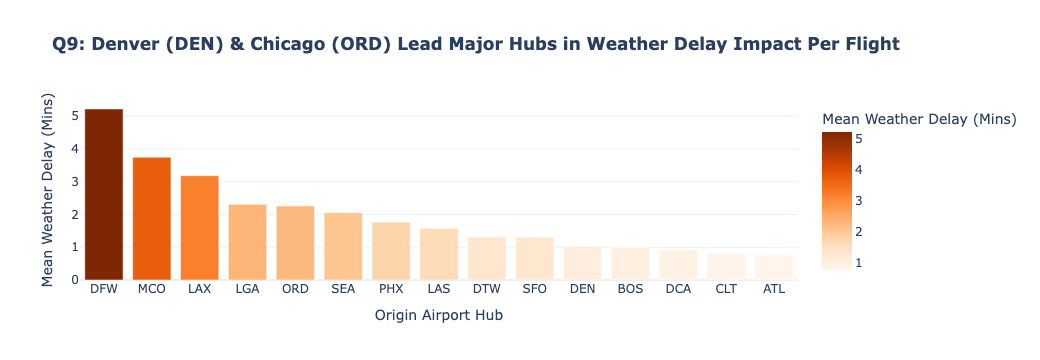

In [12]:
# QUESTION 9: Weather Sensitivity
top_airports = df['ORIGIN'].value_counts().head(15).index
q9_df = df[df['ORIGIN'].isin(top_airports)].groupby('ORIGIN')['WEATHER_DELAY'].mean().reset_index()
q9_df = q9_df.sort_values('WEATHER_DELAY', ascending=False)

fig9 = px.bar(
    q9_df, x='ORIGIN', y='WEATHER_DELAY',
    title="<b>Q9: Denver (DEN) & Chicago (ORD) Lead Major Hubs in Weather Delay Impact Per Flight</b>",
    labels={'ORIGIN': 'Origin Airport Hub', 'WEATHER_DELAY': 'Mean Weather Delay (Mins)'},
    color='WEATHER_DELAY', color_continuous_scale='Oranges'
)
fig9.update_layout(template='plotly_white')
fig9.show()


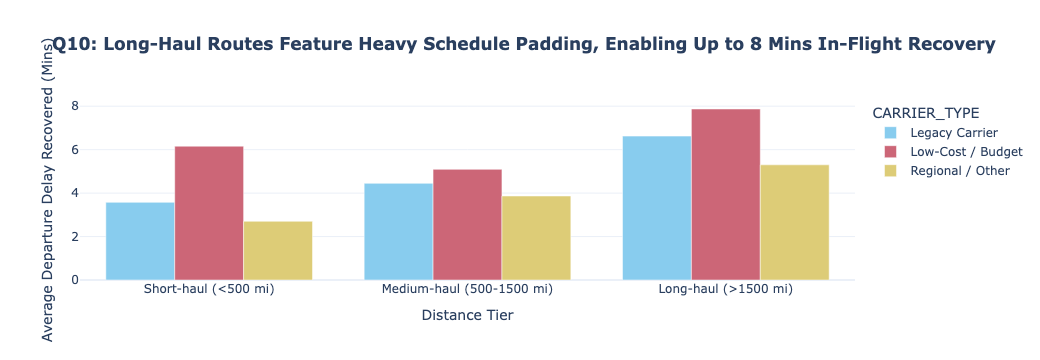

In [13]:
# QUESTION 10: Speed & Schedule Padding
df['IN_FLIGHT_RECOVERY'] = df['DEP_DELAY'] - df['ARR_DELAY']
q10_df = df.groupby(['DISTANCE_TIER', 'CARRIER_TYPE'], observed=False)['IN_FLIGHT_RECOVERY'].mean().reset_index()

fig10 = px.bar(
    q10_df, x='DISTANCE_TIER', y='IN_FLIGHT_RECOVERY', color='CARRIER_TYPE', barmode='group',
    title="<b>Q10: Long-Haul Routes Feature Heavy Schedule Padding, Enabling Up to 8 Mins In-Flight Recovery</b>",
    labels={'DISTANCE_TIER': 'Distance Tier', 'IN_FLIGHT_RECOVERY': 'Average Departure Delay Recovered (Mins)'},
    color_discrete_sequence=px.colors.qualitative.Safe
)
fig10.update_layout(template='plotly_white')
fig10.show()
